<a href="https://colab.research.google.com/github/rodrigai/Alex-s-NEUR-265-Repository/blob/main/Rodriguez_Alex_coding_homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#####Alex Rodriguez

*NEUR 265 - Introduction to Neural Data Analysis*

**3/5/2026**

In [1]:
# Imports relevant modules

import pandas as pd

import matplotlib.pyplot as plt

import scipy.stats as stats

%whos

Variable   Type      Data/Info
------------------------------
pd         module    <module 'pandas' from '/u<...>ages/pandas/__init__.py'>
plt        module    <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
stats      module    <module 'scipy.stats' fro<...>scipy/stats/__init__.py'>


In [2]:
# Loads patch_seq_expanded.csv file as a Pandas DataFrame called patch_seq

url = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'
patch_seq = pd.read_csv(url)
print(patch_seq)

           ISI  Fast_Trough Marker
0    77.337143   -49.899998    Sst
1    17.177895   -44.462498    Sst
2    48.294737   -47.350002    Sst
3     8.980000   -45.656254    Sst
4    30.315385   -50.737499    Sst
..         ...          ...    ...
360  11.052333   -54.743752  Pvalb
361   8.860360   -64.875008  Pvalb
362   9.192897   -51.312504  Pvalb
363  10.544731   -52.281254  Pvalb
364  16.396364   -61.437504  Pvalb

[365 rows x 3 columns]


Text(0, 0.5, 'Counts')

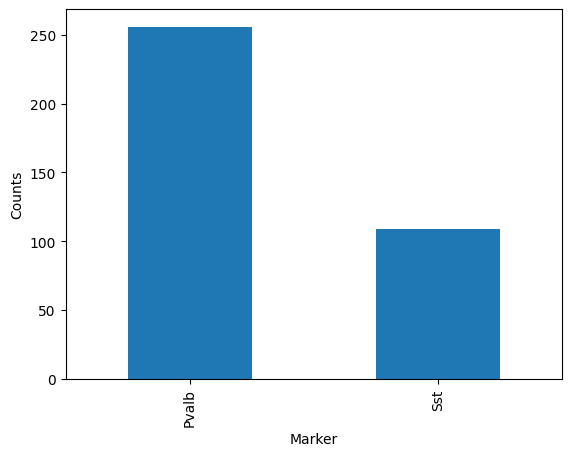

In [6]:
#Makes a bar graph that displays the value counts from the Marker column of patch_seq variable and labels x and y-axes

patch_seq['Marker'] = round(patch_seq['Marker'])
Marker_counts = patch_seq['Marker'].value_counts()
Marker_counts
Marker_counts.plot(kind = 'bar')
plt.xlabel('Marker')
plt.ylabel('Counts')



Text(0, 0.5, 'Counts')

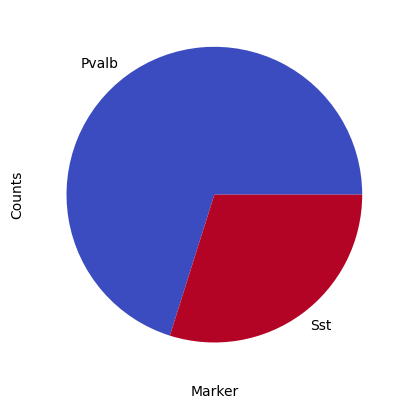

In [5]:
# Makes a pie chart of Marker_counts.plot

Marker_counts.plot(kind= 'pie', colormap= 'coolwarm')
plt.xlabel('Marker')
plt.ylabel('Counts')

Text(0, 0.5, 'Fast Trough')

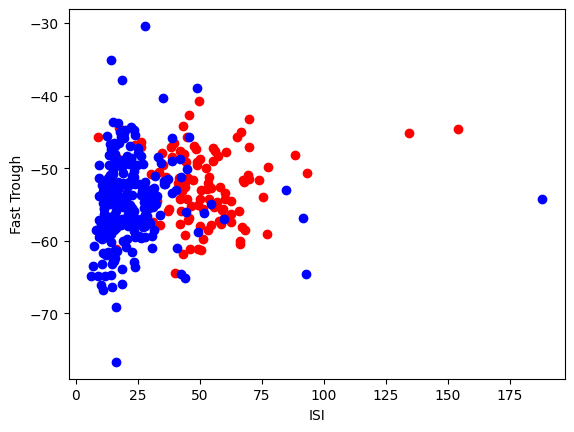

In [7]:
# Uses a fore loop to make a scatter plot of the "ISI" on the x-axis and "Fast Trough" on the y-axis with the patch_seq data frame

patch_seq_length = len(patch_seq)

for i in range(patch_seq_length):
  if patch_seq.iloc[i,2] == 'Sst':
    plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "red")

  else:
    plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "blue")

plt.xlabel('ISI')
plt.ylabel('Fast Trough')

In [8]:
# Defines patchScatter() as a function that can be called to display a scatter plot

def patchScatter():
    # First, write docstring:
    """

    """
    # Your code here!

    for i in range(patch_seq_length):
      if patch_seq.iloc[i,2] == 'Sst':
        plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "red")

      else:
        plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "blue")

    plt.show()

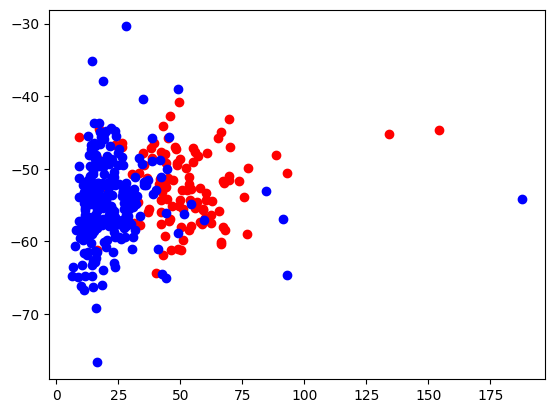

In [14]:
# Calls patchScatter() to show plot from step 6

patchScatter()

In [13]:
# Returns mean, standard deviation, and range of Fast_Trough column for Sst and Pvalb neurons

patch_seq.groupby('Marker')['Fast_Trough'].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


There are less Sst neurons observed compared to Pvalb neurons. Sst neurons have a higher mean, but a lower standard deviation. Pvalb neurons have a smaller mean, but a higher standard deviation. Pvalb has the more negative undershoot following an action potential (seen by min?), but Sst neurons have a more negative max.

In [12]:
# Returns the skewness of the "Fast_Trough" column for 'Sst' and 'Pvalb' neurons

patch_seq.groupby('Marker')['Fast_Trough'].skew()

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


Results of skew test for Fast_Trough indicate a normal distribution, as both values are between -0.5 and 0.5.

In [11]:
# Returns the skewness of the "ISI" column for 'Sst' and 'Pvalb' neurons

patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


Results of skew test for ISI indicate a skewed distribution, as both values are higher than 0.5.

In [10]:
# Isolates each group to make two seperate variables and then performs an independent samples t-test to compare 'Fast_Trough' values between the two groups

sst_neurons = patch_seq[patch_seq['Marker']=='Sst']
pvalb_neurons = patch_seq[patch_seq['Marker']=='Pvalb']
stats.ttest_ind(sst_neurons['Fast_Trough'], pvalb_neurons['Fast_Trough'])

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

The undershoot voltage does differ significantly between the two groups, as the p value is smaller than 0.05.

In [15]:
# Repeats step 14 for "ISI" but creates two new variables to input in t-test with missing values in the data deleted

sst = sst_neurons['ISI'].dropna()
pvalb = pvalb_neurons['ISI'].dropna()
stats.ttest_ind(sst, pvalb)

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

The inter-spike interval between the two groups differs significantly, as the p value is smaller than 0.05.